## Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import scipy
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold

import matplotlib.pyplot as plt

import time

import datetime

import pickle
from metrics import get_metrics

from loguru import logger

## Global Variables

In [2]:
FEAT_SCALE_TYPE = "linear_scale"    # options: "linear_scale", "standardize"

input_cols= ['b1_min','b1_mean','b1_max','b1_std','b1_median','b1_count',
            'b2_min','b2_mean','b2_max','b2_std','b2_median','b3_min',
            'b3_mean','b3_max','b3_std','b3_median','b4_min','b4_mean',
            'b4_max','b4_std','b4_median','b10_min','b10_mean','b10_max',
            'b10_std','b10_median','b11_min','b11_mean','b11_max','b11_std',
            'b11_median','b12_min','b12_mean','b12_max','b12_std','b12_median',
            'b8a_min','b8a_mean','b8a_max','b8a_std','b8a_median','LorS'
            ]

median_cols=['b1_median','b2_median','b3_median',\
                 'b4_median','b10_median','b11_median',\
                 'b12_median','b8a_median']

qa_col = 'b1_count'

cloud_cover_col = 'cloud_cover'
cloud_cut_number=50 #eliminate tiles with over 50 percent cloud cover

mgrs_col = 'MGRS'
mgrs_cut_number=0.5 #over 0.5 is 1
    
output_col = 'tss_value'
output_cols = [output_col]

coords_cols= ['lat','lon']

lors_col=['LorS']

reps=10 #number of repetitions for each model
reps=reps+1 #because of how python does its counting

varnum=len(input_cols)#

In [3]:
# Set random seeds for reproducibility
SEED = 123
np.random.seed(SEED)
random.seed(SEED)

## Data Cleaning/Filtering

In [4]:
# # PREPROCESSING
# df_merged = df_merged[df_merged[cloud_cover_col] <= cloud_cut_number] # Remove tiles with more than 50% cloud cover
# df_merged = df_merged[df_merged[mgrs_col] < mgrs_cut_number]  # Remove tiles with mgrs=1
# df_merged = df_merged.replace([np.inf, -np.inf], np.nan)    # Change inf values to nan

# df_merged = df_merged.dropna(subset=input_cols, how="any", axis=0)  # Remove rows where any feature col is nan
# df_merged = df_merged.dropna(subset=output_cols, how="any", axis=0) # Remove rows where output is nan

# data_output_array_filtered2 = df_merged[output_col].to_numpy()   # TODO: remove/rename (retained due to previous version)

# # Remove low ssc and high reflectance
# for col in median_cols:
#     df_merged = df_merged[~((df_merged[col] > 1000.0) & (df_merged[output_col] < 2.0))]
# # Remove high ssc and low reflectance
# for col in median_cols:
#     df_merged = df_merged[~((df_merged[col] < 50.0) & (df_merged[output_col] > 500.0))]

# # Remove samples with too many (lake) or too few pixels
# min_num_pixels = 10
# max_num_pixels = 250
# df_merged = df_merged[~((df_merged[qa_col] < min_num_pixels) | (df_merged[qa_col] > max_num_pixels))]

# data_input = df_merged[input_cols]  # Filter to feature columns
# data_output = df_merged[output_col]
# data_output = np.log(data_output)   # output in log scale (ln actually)
# data_coords = df_merged[coords_cols]
# data_input_coords = df_merged[input_cols + coords_cols]
# data_input_array = data_input.to_numpy()
# data_output_array = data_output.to_numpy()
# data_coords_array = data_coords.to_numpy()

# data_output_array_filtered3 = data_output_array     # TODO: remove/rename (retained due to previous version)
# data_input_array_filtered2 = data_input_array     # TODO: remove/rename (retained due to previous version)
# data_coords_array_filtered2 = data_coords_array # TODO: remove/rename (retained due to previous version)

In [5]:
# df_merged.to_csv("cleaned_data.csv", index=False)  # To be used for integration

## Train/val/test Splits

In [6]:
# # TODO: use geographic location as variable in splitting data (i.e., make sure same location doesn't appear in 2 different data splits)

# quartiles_1 = np.quantile(data_output_array_filtered3,0.25)    # Rangel NOTE: changed next 3 lines data_output_array_filtered-> data_output_array_filtered3
# quartiles_2 = np.quantile(data_output_array_filtered3,0.5)
# quartiles_3 = np.quantile(data_output_array_filtered3,0.75)
# # """
# #run through the data_output array and add classes 
# flag_class=np.zeros(len(data_output_array_filtered3))
# for i in range(0,len(data_output_array_filtered3)):
#     if (data_output_array_filtered3[i]<quartiles_1):
#         flag_class[i]=1
#     elif (data_output_array_filtered3[i]<quartiles_2):
#         flag_class[i]=2
#     elif (data_output_array_filtered3[i]<quartiles_3):
#         flag_class[i]=3
#     else:
#         flag_class[i]=4
# x_train, x_rest, y_train, y_rest = train_test_split(
#     data_input_coords, data_output, train_size=0.5,  shuffle=True, stratify=flag_class, random_state=SEED,
# )

# #now, select the validation and test 
# flag_class=np.zeros(len(y_rest))
# for i in range(0,len(y_rest)):
#     if (y_rest.values[i]<quartiles_1):
#         flag_class[i]=1
#     elif (y_rest.values[i]<quartiles_2):
#         flag_class[i]=2
#     elif (y_rest.values[i]<quartiles_3):
#         flag_class[i]=3
#     else:
#         flag_class[i]=4
# x_val, x_test, y_val, y_test = train_test_split(
#     x_rest, y_rest, test_size=0.5, train_size=0.5, shuffle=True, stratify=flag_class, random_state=SEED,
# )

In [7]:
# LOAD SPLITS BASED ON multitask model splits
# train_ssc = pd.read_csv("../data/orig_feats/train_ssc.csv")
# val_ssc = pd.read_csv("../data/orig_feats/val_ssc.csv")
# test_ssc = pd.read_csv("../data/orig_feats/test_ssc.csv")

# train_ssc_orig = pd.read_csv("../data/new_feats_v3/train.csv")
# val_ssc_orig = pd.read_csv("../data/new_feats_v3/val.csv")
# test_ssc_orig = pd.read_csv("../data/new_feats_v3/test.csv")

# train_ssc_orig = pd.read_csv("../data/opera_feats/train.csv")
# val_ssc_orig = pd.read_csv("../data/opera_feats/val.csv")
# test_ssc_orig = pd.read_csv("../data/opera_feats/test.csv")

train_ssc_orig = pd.read_csv("../opera_multitask_feats_deeplabv3p_nosnowice/train.csv")
val_ssc_orig = pd.read_csv("../opera_multitask_feats_deeplabv3p_nosnowice/val.csv")
test_ssc_orig = pd.read_csv("../opera_multitask_feats_deeplabv3p_nosnowice/test.csv")

# train_ssc_orig = pd.read_csv("../opera_multitask_feats_mobilenetv3/train.csv")
# val_ssc_orig = pd.read_csv("../opera_multitask_feats_mobilenetv3/val.csv")
# test_ssc_orig = pd.read_csv("../opera_multitask_feats_mobilenetv3/test.csv")

# train_ssc_orig = pd.read_csv("../opera_multitask_feats_satlas_si_swint/train.csv")
# val_ssc_orig = pd.read_csv("../opera_multitask_feats_satlas_si_swint/val.csv")
# test_ssc_orig = pd.read_csv("../opera_multitask_feats_satlas_si_swint/test.csv")

# train_ssc_orig = pd.read_csv("../opera_multitask_feats_satlas_si_resnet50/train.csv")
# val_ssc_orig = pd.read_csv("../opera_multitask_feats_satlas_si_resnet50/val.csv")
# test_ssc_orig = pd.read_csv("../opera_multitask_feats_satlas_si_resnet50/test.csv")

# Abltation on masks

# train_ssc_orig = pd.read_csv("../opera_multitask_feats_nowater/train.csv")
# val_ssc_orig = pd.read_csv("../opera_multitask_feats_nowater/val.csv")
# test_ssc_orig = pd.read_csv("../opera_multitask_feats_nowater/test.csv")

# train_ssc_orig = pd.read_csv("../opera_multitask_feats_nocloud/train.csv")
# val_ssc_orig = pd.read_csv("../opera_multitask_feats_nocloud/val.csv")
# test_ssc_orig = pd.read_csv("../opera_multitask_feats_nocloud/test.csv")

# train_ssc_orig = pd.read_csv("../opera_multitask_feats_nocloudshadow/train.csv")
# val_ssc_orig = pd.read_csv("../opera_multitask_feats_nocloudshadow/val.csv")
# test_ssc_orig = pd.read_csv("../opera_multitask_feats_nocloudshadow/test.csv")

# train_ssc_orig = pd.read_csv("../opera_multitask_feats_nosnowice/train.csv")
# val_ssc_orig = pd.read_csv("../opera_multitask_feats_nosnowice/val.csv")
# test_ssc_orig = pd.read_csv("../opera_multitask_feats_nosnowice/test.csv")

# train_ssc_orig = pd.read_csv("../opera_multitask_feats_nosun/train.csv")
# val_ssc_orig = pd.read_csv("../opera_multitask_feats_nosun/val.csv")
# test_ssc_orig = pd.read_csv("../opera_multitask_feats_nosun/test.csv")


train_ssc_orig = train_ssc_orig.dropna(subset = coords_cols+input_cols+output_cols, how="any")
# train_ssc_orig = train_ssc_orig[coords_cols+input_cols+output_cols]
# train_ssc_orig = train_ssc_orig.fillna(train_ssc_orig.mean())
val_ssc_orig = val_ssc_orig.dropna(subset = coords_cols+input_cols+output_cols, how="any")
test_ssc_orig = test_ssc_orig.dropna(subset = coords_cols+input_cols+output_cols, how="any")
train_ssc = train_ssc_orig[coords_cols+input_cols+output_cols]
val_ssc = val_ssc_orig[coords_cols+input_cols+output_cols]
test_ssc = test_ssc_orig[coords_cols+input_cols+output_cols]


x_train = train_ssc[coords_cols+input_cols]
x_val = val_ssc[coords_cols+input_cols]
x_test = test_ssc[coords_cols+input_cols]


y_train = np.log(train_ssc[output_col])
y_val = np.log(val_ssc[output_col])
y_test = np.log(test_ssc[output_col])

## Feature Preprocessing/Normalization

### Option 1: Linear Scaling

In [8]:
if FEAT_SCALE_TYPE == "linear_scale":    # options: "linear_scale", "standardize"
    logger.debug("Normalizing features and labels")

    y_train, y_val, y_test = (
        y_train.values.reshape((-1,)),
        y_val.values.reshape((-1,)),
        y_test.values.reshape((-1,)),
    )
    # y_train = np.concatenate((y_train, y_val), axis=0)
    # coords_train = x_train[coords_cols].to_numpy()
    # coords_val = x_val[coords_cols].to_numpy()
    # coords_test = x_test[coords_cols].to_numpy()
    x_train = x_train[input_cols].to_numpy()
    x_val = x_val[input_cols].to_numpy()
    x_test = x_test[input_cols].to_numpy()
    # x_train = np.concatenate((x_train, x_val), axis=0)


    logger.debug(f"x_train: {x_train.shape}, max: {np.max(x_train)} min: {np.min(x_train)}. y_train: {y_train.shape}, max: {np.max(y_train)} min: {np.min(y_train)}. ")
    logger.debug(f"x_val: {x_val.shape}, max: {np.max(x_val)} min: {np.min(x_val)}. y_val: {y_val.shape}, max: {np.max(y_val)} min: {np.min(y_val)}. ")
    logger.debug(f"x_test: {x_test.shape}, max: {np.max(x_test)} min: {np.min(x_test)}. y_test: {y_test.shape}, max: {np.max(y_test)} min: {np.min(y_test)}. ")


    # Normalize features and labels based on the training data
    logger.debug("Apply linear scaling to labels and features")
    y_train_max, y_train_min = np.max(y_train), np.min(y_train)
    x_train_max, x_train_min = np.max(x_train, axis=0), np.min(x_train, axis=0)

    x_train_norm = (x_train-x_train_min)/(x_train_max - x_train_min)
    x_val_norm = (x_val-x_train_min)/(x_train_max - x_train_min)
    x_test_norm = (x_test-x_train_min)/(x_train_max - x_train_min)

    y_train_norm = (y_train - y_train_min)/(y_train_max-y_train_min)    # NOTE: need to un-normalize predictions for validation and test sets


2024-04-29 16:50:07.614 | DEBUG    | __main__:<module>:2 - Normalizing features and labels
2024-04-29 16:50:07.630 | DEBUG    | __main__:<module>:19 - x_train: (15059, 42), max: 6572.0 min: -1968.0. y_train: (15059,), max: 6.363028103540465 min: -5.6987949331451615. 
2024-04-29 16:50:07.633 | DEBUG    | __main__:<module>:20 - x_val: (2072, 42), max: 6083.0 min: -1429.0. y_val: (2072,), max: 6.075346031088684 min: -5.521460917862246. 
2024-04-29 16:50:07.634 | DEBUG    | __main__:<module>:21 - x_test: (1882, 42), max: 5661.0 min: -1832.0. y_test: (1882,), max: 6.583409222158765 min: -4.828313737302301. 
2024-04-29 16:50:07.636 | DEBUG    | __main__:<module>:25 - Apply linear scaling to labels and features


In [9]:
# 15488 train, 2102 val, 1914 test

In [10]:
x_train_max, x_train_min

(array([1.37400000e+03, 1.46193250e+03, 3.30200000e+03, 8.56231069e+02,
        1.47300000e+03, 4.00000000e+02, 1.84900000e+03, 1.84900000e+03,
        4.95500000e+03, 1.03210644e+03, 1.84900000e+03, 2.02100000e+03,
        2.25669000e+03, 5.46300000e+03, 1.13810574e+03, 2.26500000e+03,
        1.86500000e+03, 2.33163036e+03, 5.58800000e+03, 1.22620062e+03,
        2.41100000e+03, 2.15000000e+02, 2.22396552e+02, 2.66000000e+02,
        5.69852447e+01, 2.22000000e+02, 2.61600000e+03, 2.61600000e+03,
        5.57700000e+03, 1.43185878e+03, 2.73600000e+03, 1.78000000e+03,
        1.90440000e+03, 6.27100000e+03, 1.23341829e+03, 2.09200000e+03,
        3.53000000e+03, 4.77360000e+03, 6.57200000e+03, 1.57899763e+03,
        4.89300000e+03, 1.00000000e+00]),
 array([-1968.        , -1610.30813953,  -946.        ,     0.        ,
        -1775.5       ,     0.        , -1784.        , -1591.15217391,
         -855.        ,     0.        , -1666.5       , -1783.        ,
        -1560.53623188

In [11]:
np.sum(x_val_norm), np.sum(x_test_norm)

(27348.65692931613, 24591.659197828638)

In [12]:
train_ssc[input_cols]

,b1_min,b1_mean,b1_max,b1_std,b1_median,b1_count,b2_min,b2_mean,b2_max,b2_std,...,b12_mean,b12_max,b12_std,b12_median,b8a_min,b8a_mean,b8a_max,b8a_std,b8a_median,LorS
0,171.0,464.645161,759.0,208.655071,482.0,31,253.0,563.935484,918.0,232.536357,...,473.225806,1226.0,395.415560,440.0,186.0,866.354839,1736.0,546.648944,947.0,0.0
1,263.0,459.236181,909.0,140.910105,414.0,199,396.0,565.020101,1078.0,152.728417,...,274.130653,1976.0,479.808707,57.0,123.0,595.532663,3000.0,550.595929,343.0,0.0
2,486.0,576.410256,820.0,104.091360,517.0,39,642.0,742.794872,1020.0,112.188756,...,573.410256,1837.0,496.058295,270.0,717.0,1121.538462,2259.0,491.420278,812.0,0.0
3,256.0,328.636364,355.0,22.135890,337.0,77,359.0,443.194805,474.0,30.927665,...,158.532468,364.0,61.755400,123.0,647.0,752.064935,1192.0,140.060593,674.0,1.0
4,10.0,275.342857,621.0,111.378426,261.0,140,93.0,328.378571,688.0,99.488942,...,169.371429,1508.0,252.461718,62.0,-91.0,510.128571,2458.0,599.881427,240.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18123,-37.0,209.258621,437.0,89.934375,217.0,58,135.0,378.155172,525.0,90.353864,...,302.706897,647.0,127.558642,284.5,514.0,1220.034483,2354.0,497.499644,1118.0,0.0
18124,254.0,302.250000,367.0,41.093643,294.0,4,400.0,427.750000,465.0,27.040479,...,299.000000,519.0,140.684043,263.0,691.0,1163.500000,1973.0,486.235283,995.0,0.0
18126,204.0,307.707692,393.0,41.970584,316.0,65,208.0,380.738462,518.0,68.392145,...,293.569231,593.0,121.081787,258.0,501.0,1095.000000,2449.0,480.442392,959.0,1.0
18127,253.0,356.534483,418.0,38.045443,366.0,58,284.0,437.534483,555.0,62.551004,...,315.534483,552.0,111.651585,289.5,559.0,1285.896552,2314.0,475.724409,1234.5,1.0


### Option 2: Standardize

In [13]:
if FEAT_SCALE_TYPE == "standardize":
    logger.debug("Standardizing features and labels")

    y_train, y_val, y_test = (
        y_train.values.reshape((-1,)),
        y_val.values.reshape((-1,)),
        y_test.values.reshape((-1,)),
    )

    mean_var_feats = {}
    x_train_norm = pd.DataFrame()
    x_val_norm = pd.DataFrame()
    x_test_norm = pd.DataFrame()
    for col in input_cols:
        if col in lors_col: # categorical column
            x_train_norm[col] = x_train[col]
            x_val_norm[col] = x_val[col]
            x_test_norm[col] = x_test[col]
            continue
        mu = np.mean(x_train[col])
        stddev = np.var(x_train[col])**0.5
        x_train_norm[col] = (x_train[col] - mu)/stddev
        x_val_norm[col] = (x_val[col] - mu)/stddev
        x_test_norm[col] = (x_test[col] - mu)/stddev

        mean_var_feats[col] = {"mu": mu, "stddev": stddev,}

    label_mu, label_stddev = np.mean(y_train), np.var(y_train)**0.5
    y_train_norm = (y_train - label_mu)/label_stddev

    x_train_norm = x_train_norm.to_numpy()
    x_val_norm = x_val_norm.to_numpy()
    x_test_norm = x_test_norm.to_numpy()

In [14]:
FEAT_SCALE_TYPE

'linear_scale'

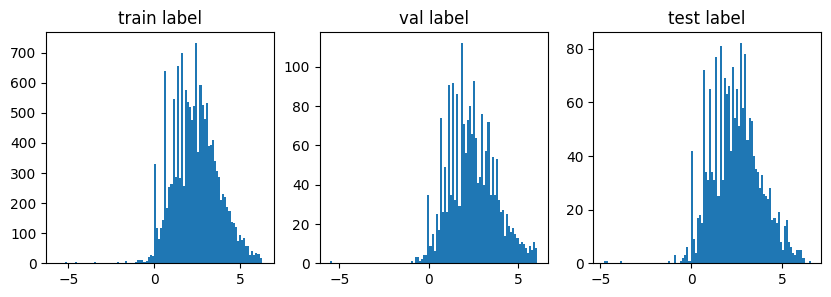

In [15]:
fig=plt.figure(figsize=(10,3))
n_rows,n_cols = 1,3

ax = fig.add_subplot(n_rows,n_cols,1)
ax.hist(y_train, bins=100)
plt.title("train label")


ax = fig.add_subplot(n_rows,n_cols,2)
ax.hist(y_val, bins=100)
plt.title("val label")


ax = fig.add_subplot(n_rows,n_cols,3)
ax.hist(y_test, bins=100)
plt.title("test label")

plt.show()

In [16]:
x_train.shape, x_val.shape, x_test.shape

((15059, 42), (2072, 42), (1882, 42))

In [17]:
x_train_norm[:,-1]

array([0., 0., 0., ..., 1., 1., 0.])

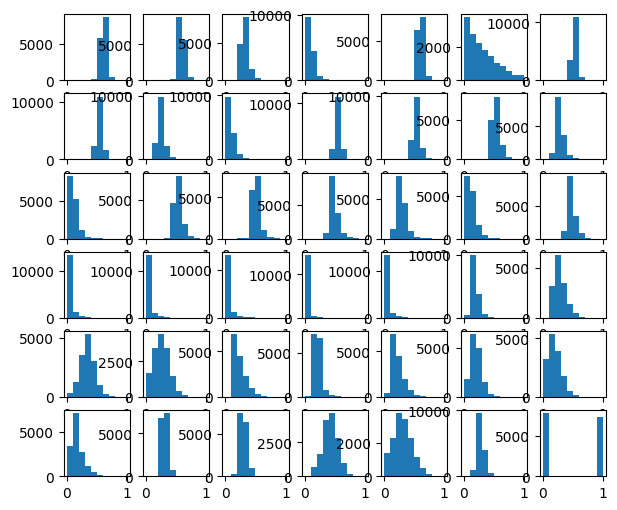

In [18]:
# plt.hist(y_train_norm)

fig=plt.figure(figsize=(7,6))
n_rows,n_cols = 6,7
for i, var_name in enumerate(input_cols):
    # print(var_name)
    ax = fig.add_subplot(n_rows,n_cols,i+1)
    ax.hist(x_train_norm[:,i], bins=10)
    # plt.title(var_name)
# plt.tight_layout()
plt.show()

# input_cols= ['b1_min','b1_mean','b1_max','b1_std','b1_median','b1_count',
#             'b2_min','b2_mean','b2_max','b2_std','b2_median','b3_min',
#             'b3_mean','b3_max','b3_std','b3_median','b4_min','b4_mean',
#             'b4_max','b4_std','b4_median','b10_min','b10_mean','b10_max',
#             'b10_std','b10_median','b11_min','b11_mean','b11_max','b11_std',
#             'b11_median','b12_min','b12_mean','b12_max','b12_std','b12_median',
#             'b8a_min','b8a_mean','b8a_max','b8a_std','b8a_median','LorS'
#             ]

## Train Model

In [19]:
# params = {
#     # "n_estimators": 100,
#     # "lambda": 1,
#     # "alpha": 0.01,
#     # "eta": 0.3,
#     # "objective": "reg:squarederror",

#     # "n_estimators": 1000,
#     # "lambda": 1,    # L2 regularization
#     # "alpha": 0.01,  # L1 regularization
#     # "eta": 0.01,
#     # "objective": "reg:squarederror",    #reg:absoluteerror
    
# #     # 'max_depth': 5,
# #     # "booster": "gblinear",
# }
# # params = {"n_estimators": 1000, 'alpha': 0.001, 'eta': 0.01, 'lambda': 3, 'max_depth': 10, 'objective': 'reg:squarederror'}
# # params = {"n_estimators": 1000, 'alpha': 0.001, 'eta': 0.01, 'lambda': 3, 'max_depth': 5, 'objective': 'reg:squarederror'}
# params = {'alpha': 0.01, 'eta': 0.05, 'lambda': 3, 'max_depth': 10, 'objective': 'reg:squarederror', "min_child_weight": 5}

# # params = {'alpha': 0.001, 'eta': 0.05, 'lambda': 3, 'max_depth': 10, 'objective': 'reg:squarederror'}

# xgb_reg = xgb.XGBRegressor(**params, seed=22)
# xgb_reg.fit(x_train_norm,y_train_norm)
# model = xgb_reg

# # import pickle

# # filename = 'xgb_model.sav'
# # pickle.dump(model, open(filename, 'wb')) 

In [20]:
# params={ 
#     'max_depth': 7,
#     'n_estimators': 500,
#     'criterion': 'squared_error',
#     'max_features': 'sqrt',
#     # 'min_samples_split': 3,
#     # 'min_samples_leaf': 23,
#     # 'bootstrap': True,
#     'min_impurity_decrease': 0.02}
# model = RandomForestRegressor(
#     **params,
# )
# model.fit(x_train_norm,y_train_norm)


In [21]:
# model = LinearRegression()
# model.fit(x_train_norm,y_train_norm)

In [22]:
param = {"batch_size":512, 'activation': 'tanh', 'alpha': 0.001, 'learning_rate': 'constant', 'learning_rate_init': 0.01, 'solver': 'lbfgs'}

model = MLPRegressor(
    **param,
)
# x = x.values
model.fit(x_train_norm,y_train_norm)

MLPRegressor(activation='tanh', alpha=0.001, batch_size=512,
             learning_rate_init=0.01, solver='lbfgs')

## Evaluate Model

In [23]:
FEAT_SCALE_TYPE, y_train_max, y_train_min

('linear_scale', 6.363028103540465, -5.6987949331451615)

In [24]:
train_pred = model.predict(x_train_norm)
if FEAT_SCALE_TYPE == "standardize":
    train_pred = (train_pred*label_stddev)+label_mu
elif FEAT_SCALE_TYPE == "linear_scale":
    train_pred = (train_pred*(y_train_max-y_train_min)) + y_train_min
train_pred = np.exp(train_pred)
train_gt = np.exp(y_train)
train_metrics = get_metrics(train_gt, train_pred)
train_metrics["corr_coeff"] = np.corrcoef(train_gt, train_pred)[0][1]

val_pred = model.predict(x_val_norm)
if FEAT_SCALE_TYPE == "standardize":
    val_pred = (val_pred*label_stddev)+label_mu
elif FEAT_SCALE_TYPE == "linear_scale":
    val_pred = (val_pred*(y_train_max-y_train_min)) + y_train_min
val_pred = np.exp(val_pred)
val_gt = np.exp(y_val)
val_metrics = get_metrics(val_gt, val_pred)
val_metrics["corr_coeff"] = np.corrcoef(val_gt, val_pred)[0][1]

test_pred = model.predict(x_test_norm)
if FEAT_SCALE_TYPE == "standardize":
    test_pred = (test_pred*label_stddev)+label_mu
elif FEAT_SCALE_TYPE == "linear_scale":
    test_pred = (test_pred*(y_train_max-y_train_min)) + y_train_min
test_pred = np.exp(test_pred)
test_gt = np.exp(y_test)
test_metrics = get_metrics(test_gt, test_pred)
test_metrics["corr_coeff"] = np.corrcoef(test_gt, test_pred)[0][1]
abs_err = np.abs(test_pred-test_gt)
E90=np.quantile(abs_err,0.9)
E95=np.quantile(abs_err,0.95)
print("TEST", E90, E95)

print(f"TRAIN: {train_metrics}")
# print(f"VAL: {val_metrics}")
print(f"TEST: {test_metrics}")

TEST 50.35478543379434 93.14533943125798
TRAIN: {'rmse': 57.80816479323391, 'mae': 20.027948417161443, 'mape': 3.2953614468587995, 'r2': -0.3280072556652054, 'bias': 10.298287301219933, 'pct_bias': -2.808648870683554, 'smape': 0.7232773742387014, 'corr_coeff': 0.24785827480700856}
TEST: {'rmse': 49.508577118471074, 'mae': 20.07548783628174, 'mape': 2.490214748068073, 'r2': 0.2214270014740093, 'bias': 14.31678106978905, 'pct_bias': -1.9790179590224906, 'smape': 0.7138516322618556, 'corr_coeff': 0.5793494594518466}


In [25]:
np.median(np.abs(train_pred-train_gt)), np.median(np.abs(val_pred-val_gt)), np.median(np.abs(test_pred-test_gt))

(5.640948015075873, 5.903249766777721, 5.711385629149973)

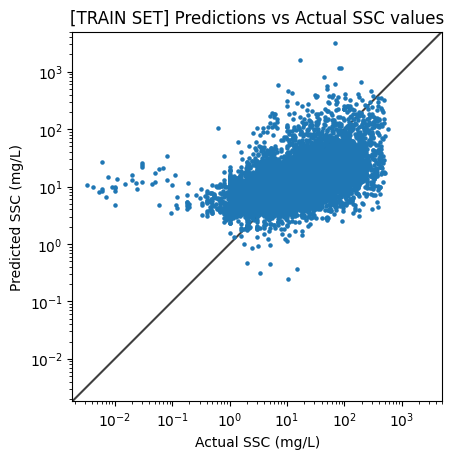

In [26]:
ax = plt.gca()
plt.scatter(train_gt, train_pred, s=5)
plt.ylabel("Predicted SSC (mg/L)")
plt.xlabel("Actual SSC (mg/L)")
plt.title("[TRAIN SET] Predictions vs Actual SSC values")
ax.set_xscale("log")
ax.set_yscale("log")
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
# now plot both limits against each other
ax.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)
plt.show()

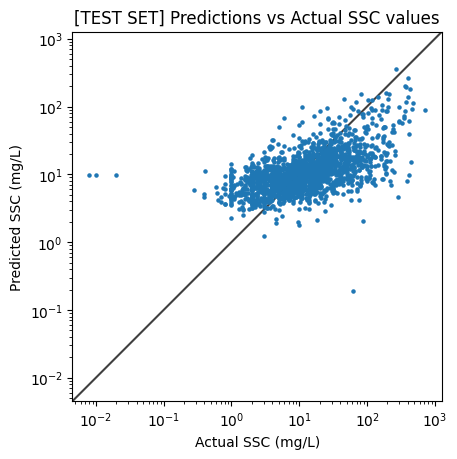

In [27]:
ax = plt.gca()
plt.scatter(test_gt, test_pred, s=5)
plt.ylabel("Predicted SSC (mg/L)")
plt.xlabel("Actual SSC (mg/L)")
plt.title("[TEST SET] Predictions vs Actual SSC values")
ax.set_xscale("log")
ax.set_yscale("log")
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
# now plot both limits against each other
ax.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)
plt.show()

In [28]:
train_ssc_orig["pred"] = train_pred
val_ssc_orig["pred"] = val_pred
test_ssc_orig["pred"] = test_pred
train_ssc_orig["pred_log"] = np.log(train_pred)
val_ssc_orig["pred_log"] = np.log(val_pred)
test_ssc_orig["pred_log"] = np.log(test_pred)
train_ssc_orig["abs_error"] = np.abs(train_gt-train_pred)
val_ssc_orig["abs_error"] = np.abs(val_gt-val_pred)
test_ssc_orig["abs_error"] = np.abs(test_gt-test_pred)

train_ssc_orig["split"] = "train"
val_ssc_orig["split"] = "val"
test_ssc_orig["split"] = "test"

all_preds_df = pd.concat([train_ssc_orig, val_ssc_orig, test_ssc_orig])
all_preds_df["tss_value_log"] = np.log(all_preds_df["tss_value"])
all_preds_df.to_csv("xgb_preds.csv", index=False)

In [29]:
"""
BEFORE
TEST 51.48562343120572 99.47431898117046
TRAIN: {'rmse': 31.068997928682535, 'mae': 10.688960703698806, 'mape': 0.4785293450546834, 'r2': 0.6373276976194471, 'bias': 8.258423009071176, 'pct_bias': -0.18084357313585175, 'smape': 0.38456941184194404, 'corr_coeff': 0.8911120689145697}
VAL: {'rmse': 48.90863814426789, 'mae': 20.225944919882135, 'mape': 2.070346900596385, 'r2': 0.22807328827784856, 'bias': 13.13580596182462, 'pct_bias': -1.583473847598621, 'smape': 0.7044934350506163, 'corr_coeff': 0.5856885831392995}
TEST: {'rmse': 53.952643557495, 'mae': 21.682631825352082, 'mape': 2.321835357006798, 'r2': 0.17663416344381833, 'bias': 15.117847059635015, 'pct_bias': -1.8129538938682839, 'smape': 0.7001497321697082, 'corr_coeff': 0.55323701874333}
median: (2.4162282180786114, 5.694640874862672, 5.857267409831523)

AFTER (v3)
TEST 55.807850646972696 108.56156616210927
TRAIN: {'rmse': 32.575088899258645, 'mae': 11.003837678374419, 'mape': 0.4806465529440974, 'r2': 0.6008995760003357, 'bias': 8.7820204182936, 'pct_bias': -0.1828734696685357, 'smape': 0.3872290671532733, 'corr_coeff': 0.8750072179795524}
VAL: {'rmse': 50.54419502718347, 'mae': 20.74755109185341, 'mape': 1.966446760955615, 'r2': 0.1807294114267728, 'bias': 13.83987380594198, 'pct_bias': -1.4891767686256876, 'smape': 0.7069334261208774, 'corr_coeff': 0.5585266252225237}
TEST: {'rmse': 55.16592240759148, 'mae': 22.200770829163428, 'mape': 2.787343038921474, 'r2': 0.14257967800932336, 'bias': 16.012467857712146, 'pct_bias': -2.2740914897971716, 'smape': 0.7110897155233874, 'corr_coeff': 0.5268079070531886}
median: (2.389042854309082, 6.042709179685162, 5.923256158828735)

AFTER
TEST 57.35826780319203 113.32419495582543
TRAIN: {'rmse': 37.6643188105519, 'mae': 12.928463157282795, 'mape': 0.5968121299056399, 'r2': 0.4670086858420661, 'bias': 10.389697543624477, 'pct_bias': -0.26963820850680226, 'smape': 0.4378820579081715, 'corr_coeff': 0.8237922861477024}
VAL: {'rmse': 53.40989274441661, 'mae': 21.87217438603291, 'mape': 1.867321674208809, 'r2': 0.07944796806159848, 'bias': 15.190241948814183, 'pct_bias': -1.3602014053978513, 'smape': 0.752460818728174, 'corr_coeff': 0.4453684367653434}
TEST: {'rmse': 58.339124777923665, 'mae': 23.67782731239133, 'mape': 2.7860913156528104, 'r2': 0.037308352182170545, 'bias': 17.235777547346807, 'pct_bias': -2.243729457026637, 'smape': 0.7645165526199075, 'corr_coeff': 0.40150907990935353}
median: (2.7826318740844727, 6.303797006607052, 6.64225339889526)


v2
TEST 56.26689634323113 113.31696662902819
TRAIN: {'rmse': 37.71671149753026, 'mae': 12.93372457665889, 'mape': 0.5900428174780844, 'r2': 0.4655248268317951, 'bias': 10.419036264192291, 'pct_bias': -0.26357709385861117, 'smape': 0.43642931891639086, 'corr_coeff': 0.8313395015001807}
VAL: {'rmse': 53.12594475462236, 'mae': 21.738055950344602, 'mape': 2.063132073393603, 'r2': 0.0892099826433117, 'bias': 15.268458526511598, 'pct_bias': -1.559753074688291, 'smape': 0.748346181993687, 'corr_coeff': 0.48055141052952954}
TEST: {'rmse': 58.324232148196806, 'mae': 23.529816952143136, 'mape': 3.0349032733032426, 'r2': 0.03779979528670929, 'bias': 17.34475323623967, 'pct_bias': -2.4988726356193847, 'smape': 0.7585419475953714, 'corr_coeff': 0.4142086527821604}
median: (2.7703628540039062, 6.4704930782318115, 6.46993808746338)

"""

"\nBEFORE\nTEST 51.48562343120572 99.47431898117046\nTRAIN: {'rmse': 31.068997928682535, 'mae': 10.688960703698806, 'mape': 0.4785293450546834, 'r2': 0.6373276976194471, 'bias': 8.258423009071176, 'pct_bias': -0.18084357313585175, 'smape': 0.38456941184194404, 'corr_coeff': 0.8911120689145697}\nVAL: {'rmse': 48.90863814426789, 'mae': 20.225944919882135, 'mape': 2.070346900596385, 'r2': 0.22807328827784856, 'bias': 13.13580596182462, 'pct_bias': -1.583473847598621, 'smape': 0.7044934350506163, 'corr_coeff': 0.5856885831392995}\nTEST: {'rmse': 53.952643557495, 'mae': 21.682631825352082, 'mape': 2.321835357006798, 'r2': 0.17663416344381833, 'bias': 15.117847059635015, 'pct_bias': -1.8129538938682839, 'smape': 0.7001497321697082, 'corr_coeff': 0.55323701874333}\nmedian: (2.4162282180786114, 5.694640874862672, 5.857267409831523)\n\nAFTER (v3)\nTEST 55.807850646972696 108.56156616210927\nTRAIN: {'rmse': 32.575088899258645, 'mae': 11.003837678374419, 'mape': 0.4806465529440974, 'r2': 0.600899